# Construction Site Helmet Detection CNN Model Training Pipeline


- Ingests source dataset with annotated bounding boxes
- Extracts individual objects using provided bounding boxes
- Normalizes samples by cropping and resizing to 100×100 with centered subjects
- Constructs a cleaned, single-subject image dataset for training
- Trains a CNN classifier (VGG16 transfer learning) on curated data

Other Datasets and Cross Validation Notebook available on GitHub
https://github.com/DanielLevenstein/Helmet_CNN_Model_Training_Notebooks

## Load Data from Original Dataset

Source: https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection
Author: Larxel (andrewmvd)

Bounding box annotations are provided in the PASCAL VOC format


In [1]:
import kagglehub

# Path to Kaggle Helmet Dataset
path = kagglehub.dataset_download("andrewmvd/hard-hat-detection")
download_path = path
path_annotations = download_path +'/annotations'
path_images = download_path+'/images'
print(path_annotations)
print(path_images)

/kaggle/input/datasets/andrewmvd/hard-hat-detection/annotations
/kaggle/input/datasets/andrewmvd/hard-hat-detection/images


### Dataset Description
- Contains bounding boxes for 3 objects. ['person', 'head', 'helmet']
- There are twice as many images in this dataset with helmets compared to without.
- There aren't enough samples with the person bounding box to be useful.

In [2]:
import os
import pandas as pd
import xml.etree.ElementTree as ET


def parse_xml_to_dataframe(path):
    data = []
    for file in os.listdir(path):
        if file.startswith("hard_hat_workers") and file.endswith(".xml"):
            tree = ET.parse(os.path.join(path, file))
            root = tree.getroot()
            for item in root:
                data.append({child.tag: child.text for child in item})
    return pd.DataFrame(data)


df = parse_xml_to_dataframe(path_annotations)


In [3]:
df['name'].value_counts()

name
helmet    18966
head       5785
person      751
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='name'>

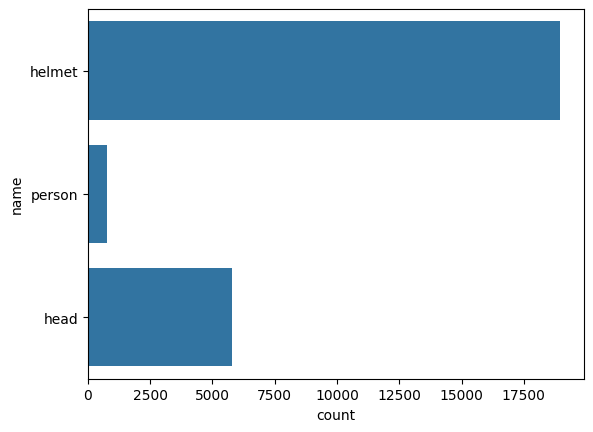

In [4]:
import seaborn as sns
sns.countplot(df['name'])

## Splitting Dataset
- Cropping images to 100x100 using predefined bounding boxes from source data.
- Holding out some test data at the file system level for later use

In [5]:
full_annotation_set = os.listdir(path_annotations)
train_files = full_annotation_set[:int(len(full_annotation_set) * 0.95)]
test_files = full_annotation_set[int(len(full_annotation_set) * 0.95):]


In [6]:
print(len(train_files))
print(len(test_files))

4750
250


In [7]:
import shutil

# Clean Data Directory
CROPPED_SIZE = 100
MIN_SIZE_CROPPED = 50
DATASET_3_OUTPUT = "data/dataset3"
DATASET_3_TEST_OUTPUT = "data/dataset3_test"

CLASS_DIRECTORY = ["with_helmet", "without_helmet"]
DATASETS = [DATASET_3_OUTPUT, DATASET_3_TEST_OUTPUT]
for dataset in DATASETS:
    if os.path.exists(dataset):
        shutil.rmtree(dataset)
    os.makedirs(dataset)
    for class_name in CLASS_DIRECTORY:
        class_directory = os.path.join(dataset, class_name)
        os.makedirs(class_directory)


In [8]:
import os
import cv2
import pandas as pd
import xml.etree.ElementTree as ET

# Function to parse bounding boxes from PASCAL VOC XML files into a dataframe
def parse_voc_annotation(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    bboxes = []
    for obj in root.findall('object'):
        bbox = obj.find('bndbox')
        x_min = int(bbox.find('xmin').text)
        y_min = int(bbox.find('ymin').text)
        x_max = int(bbox.find('xmax').text)
        y_max = int(bbox.find('ymax').text)
        class_name = obj.find('name').text
        bboxes.append({'x_min': x_min, 'y_min': y_min, 'x_max': x_max, 'y_max': y_max, 'class': class_name})
    return pd.DataFrame(bboxes)

def generate_cropped_images(annotation_set, output_dir):
    print(f"Generating cropped images for {len(annotation_set)} files...")
    # Crop images based on annotations in dataframe
    for annotation_file in annotation_set:
        if annotation_file.endswith('.xml'):
            image_id = os.path.splitext(annotation_file)[0]
            image_path = os.path.join(path_images, image_id + '.png')
            # print(f"Processing {annotation_file} for image {image_id}...")
            annotation_file = os.path.join(path_annotations, annotation_file)
            if os.path.exists(annotation_file):
                # print(f"Loading image {image_id} from {image_path}...")
                image = cv2.imread(image_path)
                if image is not None:  # Check if the image was loaded successfully
                    bboxes_df = parse_voc_annotation(annotation_file)

                    for i, row in bboxes_df.iterrows():
                        if row['x_max'] - row['x_min'] > MIN_SIZE_CROPPED and row['y_max'] - row['y_min'] > MIN_SIZE_CROPPED:
                            x_min, y_min, x_max, y_max, class_name = row['x_min'], row['y_min'], row['x_max'], row['y_max'], \
                            row['class']
                            # Calculate the center of a cropped image.
                            x_center = (x_min + x_max) // 2
                            y_center = (y_min + y_max) // 2
                            # Calculate min_x, and min_y based on center
                            x_min_modified = x_center - CROPPED_SIZE // 2
                            y_min_modified = y_center - CROPPED_SIZE // 2
                            x_min = max(x_min_modified, 0)
                            y_min = max(y_min_modified, 0)
                            # Set x_max and y_max based on x_min, and y_min
                            x_max_modified = x_min + CROPPED_SIZE
                            y_max_modified = y_min + CROPPED_SIZE
                            x_max = min(x_max_modified, image.shape[1])
                            y_max = min(y_max_modified, image.shape[0])
                            # Adjust min_x, and min_y a second time to account for images near the edge of the original image.
                            x_min = x_max - CROPPED_SIZE if x_min < 0 else x_min
                            y_min = y_max - CROPPED_SIZE if y_min < 0 else y_min
                            # print(f"Cropping image {image_id} with bounding box ({x_min}, {y_min}, {x_max}, {y_max})")
                            cropped_image = image[y_min:y_max, x_min:x_max]
                            if class_name == "helmet":
                                class_directory = f"{output_dir}/with_helmet"
                                output_image_path = os.path.join(class_directory, f"{image_id}_cropped_{i}.png")
                                cv2.imwrite(output_image_path, cropped_image)
                            elif class_name == "head":
                                class_directory = f"{output_dir}/without_helmet"
                                output_image_path = os.path.join(class_directory, f"{image_id}_cropped_{i}.png")
                                cv2.imwrite(output_image_path, cropped_image)
                else:
                    print(f"Warning: Unable to load image {image_path}. Skipping.")
generate_cropped_images(annotation_set=train_files, output_dir=DATASET_3_OUTPUT)
generate_cropped_images(annotation_set=test_files, output_dir=DATASET_3_TEST_OUTPUT)

Generating cropped images for 4750 files...
Generating cropped images for 250 files...


In [9]:
from PIL import Image
import numpy as np
def load_image_paths_to_df(root_dir, image_size=(CROPPED_SIZE, CROPPED_SIZE)):
    data = []

    for label in os.listdir(root_dir):
        label_path = os.path.join(root_dir, label)

        if os.path.isdir(label_path):
            for file in os.listdir(label_path):
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(label_path, file)

                    img = Image.open(file_path).convert("RGB")
                    img = img.resize(image_size)
                    img_array = np.array(img)

                    data.append({
                        "label": label,
                        "file_path": file_path
                    })

    df = pd.DataFrame(data)
    return df

dataset3_file_paths = load_image_paths_to_df(DATASET_3_OUTPUT)
test_df = load_image_paths_to_df(DATASET_3_TEST_OUTPUT)
dataset3_file_paths["label_enum"] = dataset3_file_paths["label"].replace({"with_helmet": 1, "without_helmet" : 0})
test_df['label_enum'] = test_df["label"].replace({"with_helmet": 1, "without_helmet" : 0})


/tmp/ipykernel_23/807583900.py:28: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset3_file_paths["label_enum"] = dataset3_file_paths["label"].replace({"with_helmet": 1, "without_helmet" : 0})
/tmp/ipykernel_23/807583900.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_df['label_enum'] = test_df["label"].replace({"with_helmet": 1, "without_helmet" : 0})


## Data Distribution

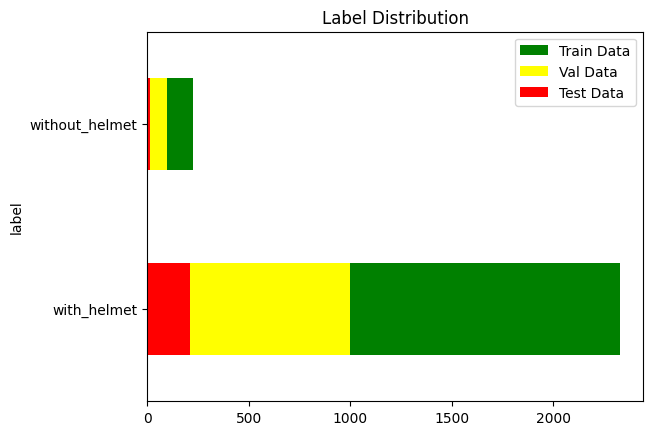

In [10]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
train_df, val_df = train_test_split(dataset3_file_paths, test_size=0.3, stratify=dataset3_file_paths['label'], random_state=42)

train_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='green', label='Train Data')
val_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='yellow', label='Val Data')
test_df.label.value_counts().sort_index().plot(kind='barh', title='Label Distribution', color='red', label='Test Data')
plt.legend();


In [11]:
import tensorflow as tf
def convert_to_tf_dataset(df):
    images = []
    labels = []
    for index, row in df.iterrows():
        file_path = row["file_path"]
        label = row["label_enum"]
        if os.path.exists(file_path):
            image = Image.open(file_path).convert("RGB")
            image = image.resize((CROPPED_SIZE, CROPPED_SIZE))
            image = np.array(image).astype('float32')
            images.append(image)
            labels.append(label)
        else:
            print(f"File not found: {file_path}")
    images = np.array(images)
    labels = np.array(labels)
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))
    dataset = dataset.map(lambda x, y: (tf.image.per_image_standardization(x), y)).batch(32)
    return dataset


# Convert train_df and test_df to TensorFlow datasets
train_ds = convert_to_tf_dataset(train_df)
val_ds = convert_to_tf_dataset(val_df)

2026-05-04 18:29:08.638422: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777919349.137808      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777919349.317238      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777919350.500085      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777919350.500140      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777919350.500143      23 computation_placer.cc:177] computation placer alr

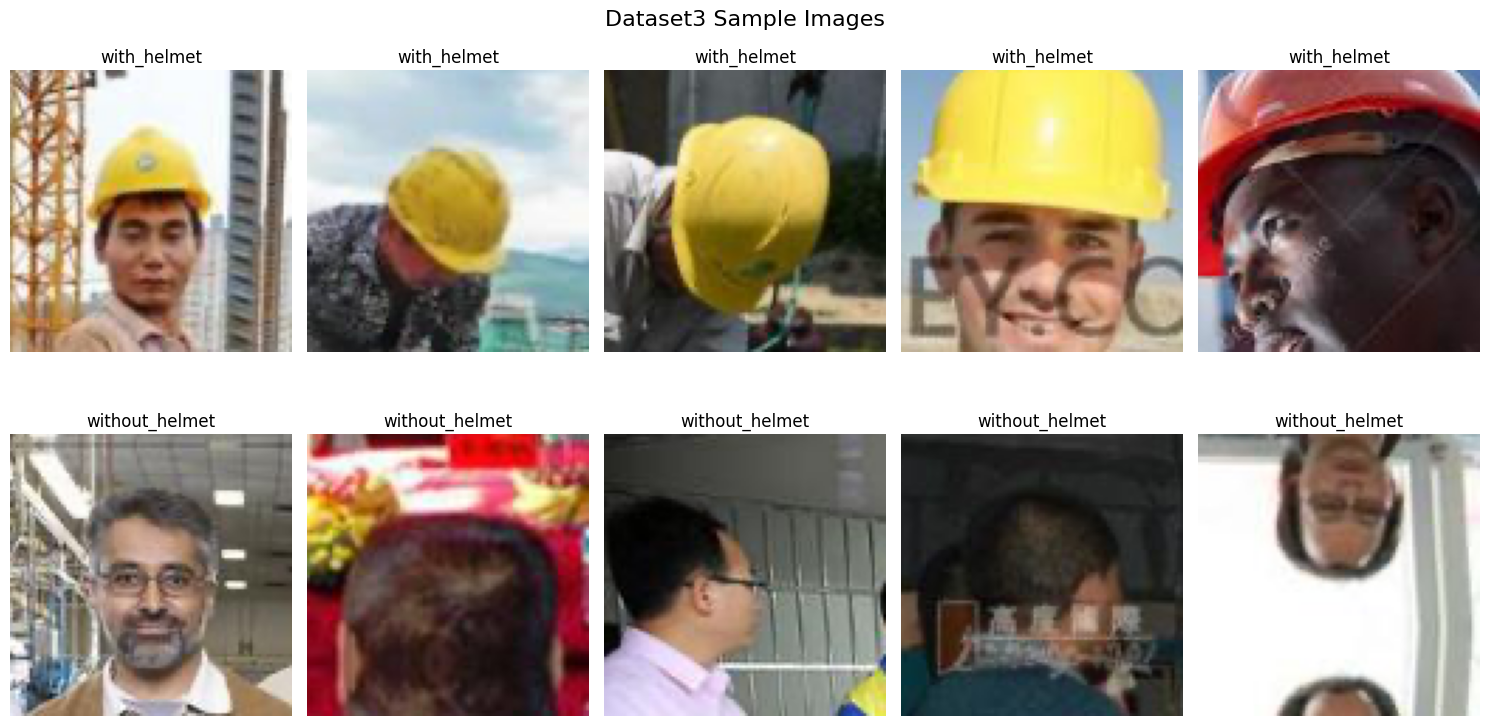

In [12]:
# Display 5 random images from each class
def display_random_images(dataframe, num_images=5, figure_name="dataset3_random_samples.png"):
    # Group by labels
    grouped = dataframe.groupby("label")
    num_classes = len(grouped)

    fig, axes = plt.subplots(
        nrows=num_classes,
        ncols=num_images,
        figsize=(15, 4 * num_classes)
    )
    axes = axes if num_classes > 1 else [axes]  # Handle single row case correctly

    for (label, group), ax_row in zip(grouped, axes):
        sampled_group = group.sample(n=min(num_images, len(group)), random_state=42)
        for i, (_, row) in enumerate(sampled_group.iterrows()):
            img = Image.open(row["file_path"]).convert("RGB")
            ax_row[i].imshow(img)
            ax_row[i].axis("off")
            ax_row[i].set_title(label, fontsize=12)
    plt.tight_layout()
    plt.suptitle("Dataset3 Sample Images", fontsize=16)
    plt.show()
display_random_images(train_df, num_images=5)

### Observations
- I noticed that many of the images in this set have mirroring artifacts, which is something I saw in the dataset0 from the UT project.
- The no helmet samples in this dataset consist mainly of workplace managers which could bias the results.

## Run CNN on cropped Images

In [13]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import tensorflow as tf
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense

# Load VGG16 base (no top classifier)
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(CROPPED_SIZE, CROPPED_SIZE, 3)  # adjust if needed
)

# Freeze base layers
for layer in vgg_base.layers:
    layer.trainable = False

# Custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(100, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(1, activation="sigmoid")(x)  # binary classification

# Final model
model_3 = Model(inputs=vgg_base.input, outputs=output)
model_3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
history_3 = model_3.fit(train_ds, validation_data=val_ds, epochs=10, batch_size=32)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10


I0000 00:00:1777919400.223084      71 service.cc:152] XLA service 0x7b869800e820 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777919400.223125      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777919400.223131      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777919400.845594      71 cuda_dnn.cc:529] Loaded cuDNN version 91002


 3/80 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.8194 - loss: 0.4653

I0000 00:00:1777919405.644371      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 137ms/step - accuracy: 0.9029 - loss: 0.2969 - val_accuracy: 0.9507 - val_loss: 0.1294
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9502 - loss: 0.1380 - val_accuracy: 0.9653 - val_loss: 0.1006
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9711 - loss: 0.0968 - val_accuracy: 0.9644 - val_loss: 0.0892
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9758 - loss: 0.0783 - val_accuracy: 0.9671 - val_loss: 0.0830
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9784 - loss: 0.0722 - val_accuracy: 0.9680 - val_loss: 0.0797
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accuracy: 0.9826 - loss: 0.0603 - val_accuracy: 0.9699 - val_loss: 0.0772
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9804 - loss: 0.0568 - val_accuracy: 0.9689 - val_loss: 0.0768
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9794 - loss: 0.0555 - val_accuracy: 0.9689 - val_loss: 

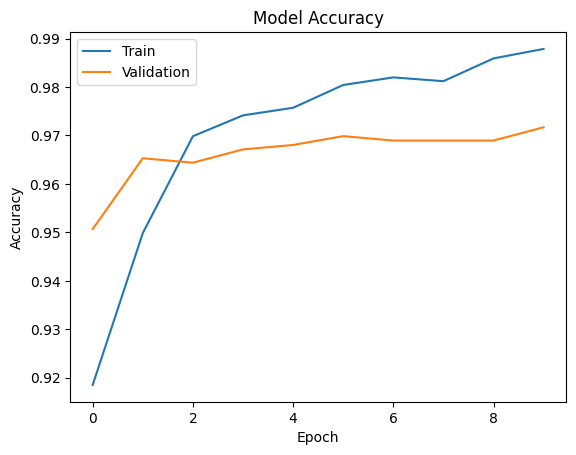

In [14]:
def plot_history(history):
    # Plot training & validation accuracy values
    plt.plot(history.history.get('accuracy', []))  # Fix: added .get() to handle missing keys
    plt.plot(history.history.get('val_accuracy', []))  # Fix: added .get() to handle missing keys
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')  # Uncommented ylabel
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_history(history_3)

In [15]:
# Assuming validation dataset (val_ds) results and true labels
val_images, val_labels = zip(*[(x.numpy(), y.numpy()) for x, y in val_ds.unbatch()])  # Unbatch validation data
val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Generate predictions for validation dataset
val_predictions = (model_3.predict(val_images) > 0.5).astype(int)

# Assuming test dataset (test_df) results and true labels
test_images, test_labels = zip(*[
    (np.array(Image.open(row["file_path"]).resize((CROPPED_SIZE, CROPPED_SIZE))).astype('float32'), row["label_enum"])
    for _, row in test_df.iterrows()
])
test_images = np.array(test_images)
test_labels = np.array(test_labels)

# Generate predictions for test dataset
test_predictions = (model_3.predict(test_images) > 0.5).astype(int)

total = val_images.size + test_images.size

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step


In [16]:
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

# Calculate accuracy, precision, and recall
accuracy_val = accuracy_score(val_labels, val_predictions)
precision_val = precision_score(val_labels, val_predictions)
recall_val = recall_score(val_labels, val_predictions)
f1_score_val = f1_score(val_labels, val_predictions)

accuracy_test = accuracy_score(test_labels, test_predictions)
precision_test = precision_score(test_labels, test_predictions)
recall_test = recall_score(test_labels, test_predictions)
f1_score_test = f1_score(test_labels, test_predictions)
# Create a dataframe to display the metrics
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Validation": [accuracy_val, precision_val, recall_val, f1_score_val],
    "Test": [accuracy_test, precision_test, recall_test, f1_score_test]
})

In [17]:
metrics_df.head()

,Metric,Validation,Test
0,Accuracy,0.971689,0.955947
1,Precision,0.987891,0.955157
2,Recall,0.980962,1.000000
3,F1 Score,0.984414,0.977064


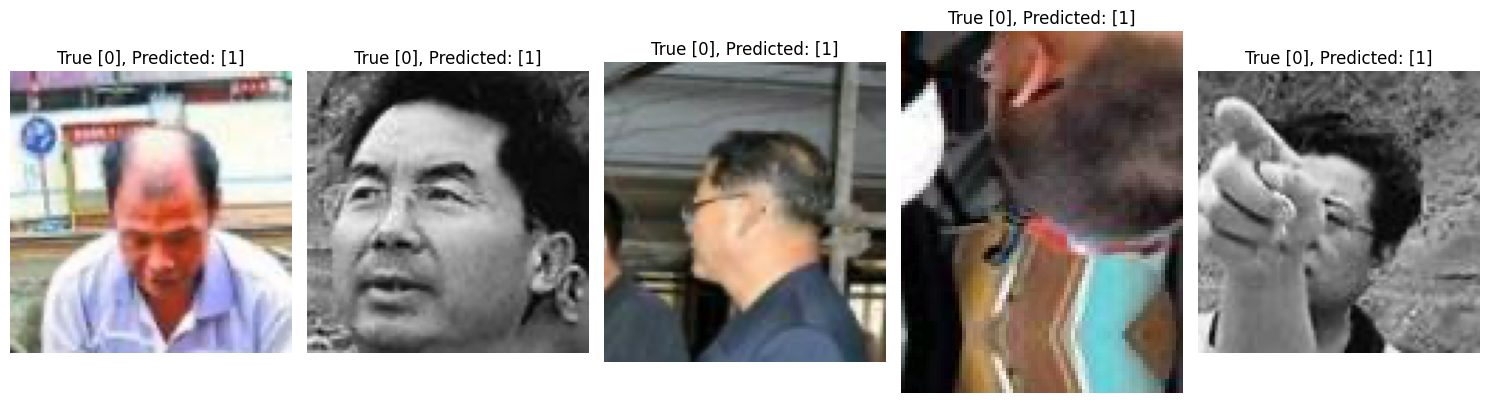

In [18]:
# Display random incorrectly categorized images
from sklearn.metrics import confusion_matrix
import random

# Confusion matrix to find misclassified images
cm = confusion_matrix(test_labels, test_predictions)
false_categorizations = [
    i for i in range(len(test_labels)) if test_labels[i] !=  test_predictions[i]
]

if false_categorizations:
    sampled_indices = random.sample(false_categorizations, min(5, len(false_categorizations)))
    plt.figure(figsize=(15, 5))
    for idx, random_index in enumerate(sampled_indices):
        misclassified_image_path = test_df.iloc[random_index]["file_path"]
        misclassified_image = np.array(Image.open(misclassified_image_path).convert("RGB"))
        plt.subplot(1, 5, idx + 1)
        plt.imshow(misclassified_image)
        plt.title(f"True [{test_labels[random_index]}], Predicted: {test_predictions[random_index]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified 'With Helmet' images found.")


# Dataset3 Summary
- Model3 has the highest overall accuracy so far and does not appear to display the precision issues we saw for Model2.
- Some of the mis-categorized images in this dataset contain helmet images in the background, which could explain why they got miscategorized.
- This dataset contains ~3000 images and has more samples with helmets than without.
- This training dataset was generated from bounding box data construction site photographs.
- All images are cropped at exactly 100x100 pixels, and samples with features smaller than 50 px are removed from the dataset.